# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [ ]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv", delimiter=',')

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [ ]:
#Seu código aqui para a média

df.groupby("Categoria")["Preco_Normal"].mean().round(2)

,Preco_Normal
Categoria,
belleza-y-cuidado-personal,1783.56
comidas-preparadas,3095.04
congelados,2108.04
frutas,1724.47
instantaneos-y-sopas,765.49
lacteos,2385.22
verduras,1343.30


In [ ]:
#Seu código aqui para a mediana
df.groupby("Categoria")["Preco_Normal"].median().round(2)


,Preco_Normal
Categoria,
belleza-y-cuidado-personal,1569.0
comidas-preparadas,3290.0
congelados,1519.0
frutas,1195.0
instantaneos-y-sopas,439.0
lacteos,989.0
verduras,1180.0


Digite aqui as categorias: Todas as categorias parecem ter seus valores acima e abaixo da mediana. Porém, há categorias que têm valores que estão muito distoantes. São elas: congelados, frutas, instantaneos-y-sopas, lacteos (este sendo o que mais chama a atenção) e verduras.

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [ ]:
#Seu código aqui
df.groupby("Categoria")["Preco_Normal"].std().round(2)

,Preco_Normal
Categoria,
belleza-y-cuidado-personal,2210.04
comidas-preparadas,2019.91
congelados,2111.54
frutas,1639.15
instantaneos-y-sopas,1170.23
lacteos,3925.82
verduras,1012.70


Digite nesse campo o comportamento que você identificou.

O desvio padrão confirma o que verificamos anteriormente: a categoria lacteos está com um grande desvio, o que indica que os valores estão muito dispersos e aparentemente há valores que estão puxando a média para cima.

Uma surpresa, porém, foi a categoria belleza-cuidado-personel, que tem o segundo desvio padrão mais alto. Entrenato, isso pode indicar apenas uma variação grande de valores, visto que a média e mediana estão próximas.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

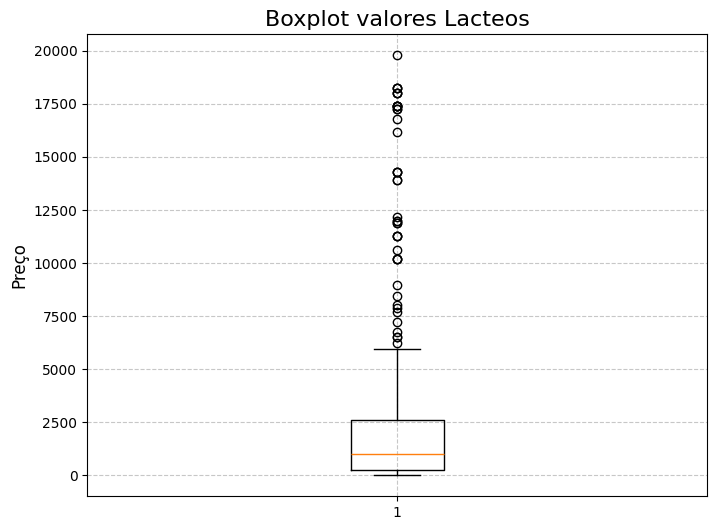

In [ ]:
#Seu código aqui
lac = df.loc[df['Categoria'] == 'lacteos']

plt.figure(figsize=(8,6))
plt.boxplot(lac['Preco_Normal'])
plt.title("Boxplot valores Lacteos", fontsize=16)
plt.ylabel("Preço", fontsize=12)
plt.grid(True, linestyle = "--", alpha=0.7)
plt.show()

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

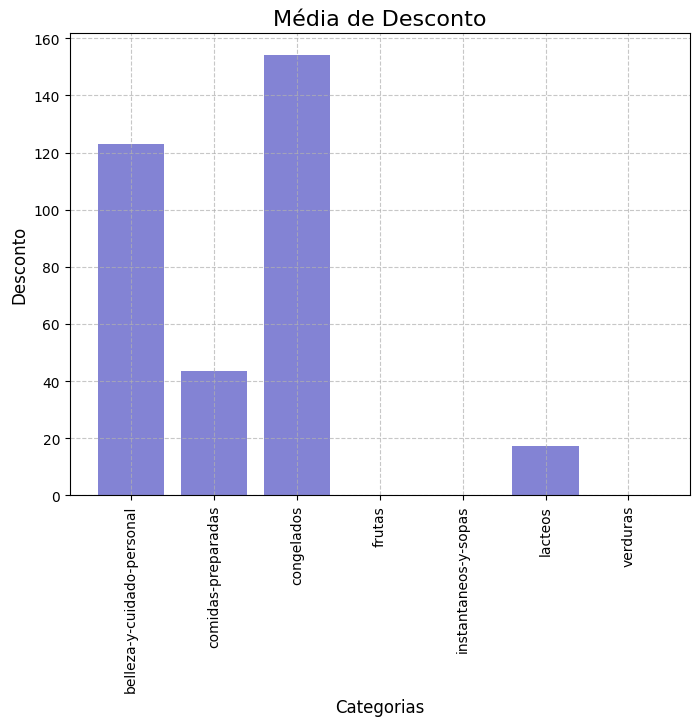

In [ ]:
# Seu código aqui
plt.figure(figsize=(8,6))
media_desconto = df.groupby("Categoria")["Desconto"].mean().round(2)
plt.bar(media_desconto.index, media_desconto, color="#8383D4")
plt.title("Média de Desconto", fontsize=16)
plt.xlabel("Categorias", fontsize=12)
plt.ylabel("Desconto", fontsize=12)
plt.grid(True, linestyle = "--", alpha=0.7)
plt.xticks(rotation=90)
plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [ ]:
# Seu código aqui
categoria_marca = df.groupby(["Categoria", "Marca"])["Desconto"].mean().round(2).reset_index()

fig = px.treemap(categoria_marca,
                 path= ["Categoria", "Marca"],
                 values="Desconto",
                 title="Média de Desconto por Categoria e Marca")

fig.show()